In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import scienceplots
from utils import load_metrics_df

# Apply SciencePlots style for ACL-quality publication figures
plt.style.use(['science', 'ieee', 'grid', 'no-latex'])

# Set default figure parameters for publication quality
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 20,
    'figure.titlesize': 26,
})

# Unified styling constants
STYLE = {
    # Grid
    'grid_linestyle': '--',
    'grid_alpha': 0.4,
    'grid_linewidth': 0.5,
    
    # Spines
    'spine_linewidth': 0.5,
    'hide_top': True,
    'hide_right': True,
    
    # Bars
    'bar_edgecolor': 'black',
    'bar_linewidth': 0.5,
    'bar_alpha': 0.9,
    'bar_width': 0.75,
    
    # Text labels
    'value_label_fontsize': 20,
    'title_fontsize': 24,
    'title_fontweight': 'bold',
    'title_pad': 10,
    'axis_label_fontsize': 20,
    'axis_label_fontweight': 'medium',
    'tick_label_fontsize': 18,
    
    # Legend
    'legend_fontsize': 18,
    'legend_frameon': True,
    'legend_fancybox': False,
    'legend_shadow': False,
    'legend_framealpha': 1.0,
    'legend_edgecolor': 'black',
    'legend_frame_linewidth': 0.5,
    'legend_bbox_to_anchor': (0.5, 1.02),
    
    # Figure
    'fig_dpi': 300,
    'fig_facecolor': 'white',
    'fig_tight_rect': [0, 0, 1, 0.96],
}

def apply_axis_styling(ax):
    """Apply unified axis styling to any axis"""
    ax.yaxis.grid(True, linestyle=STYLE['grid_linestyle'], 
                  alpha=STYLE['grid_alpha'], linewidth=STYLE['grid_linewidth'])
    ax.set_axisbelow(True)
    if STYLE['hide_top']:
        ax.spines['top'].set_visible(False)
    if STYLE['hide_right']:
        ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(STYLE['spine_linewidth'])
    ax.spines['bottom'].set_linewidth(STYLE['spine_linewidth'])

def apply_legend_styling(legend):
    """Apply unified legend styling"""
    legend.get_frame().set_linewidth(STYLE['legend_frame_linewidth'])

342
1009
450


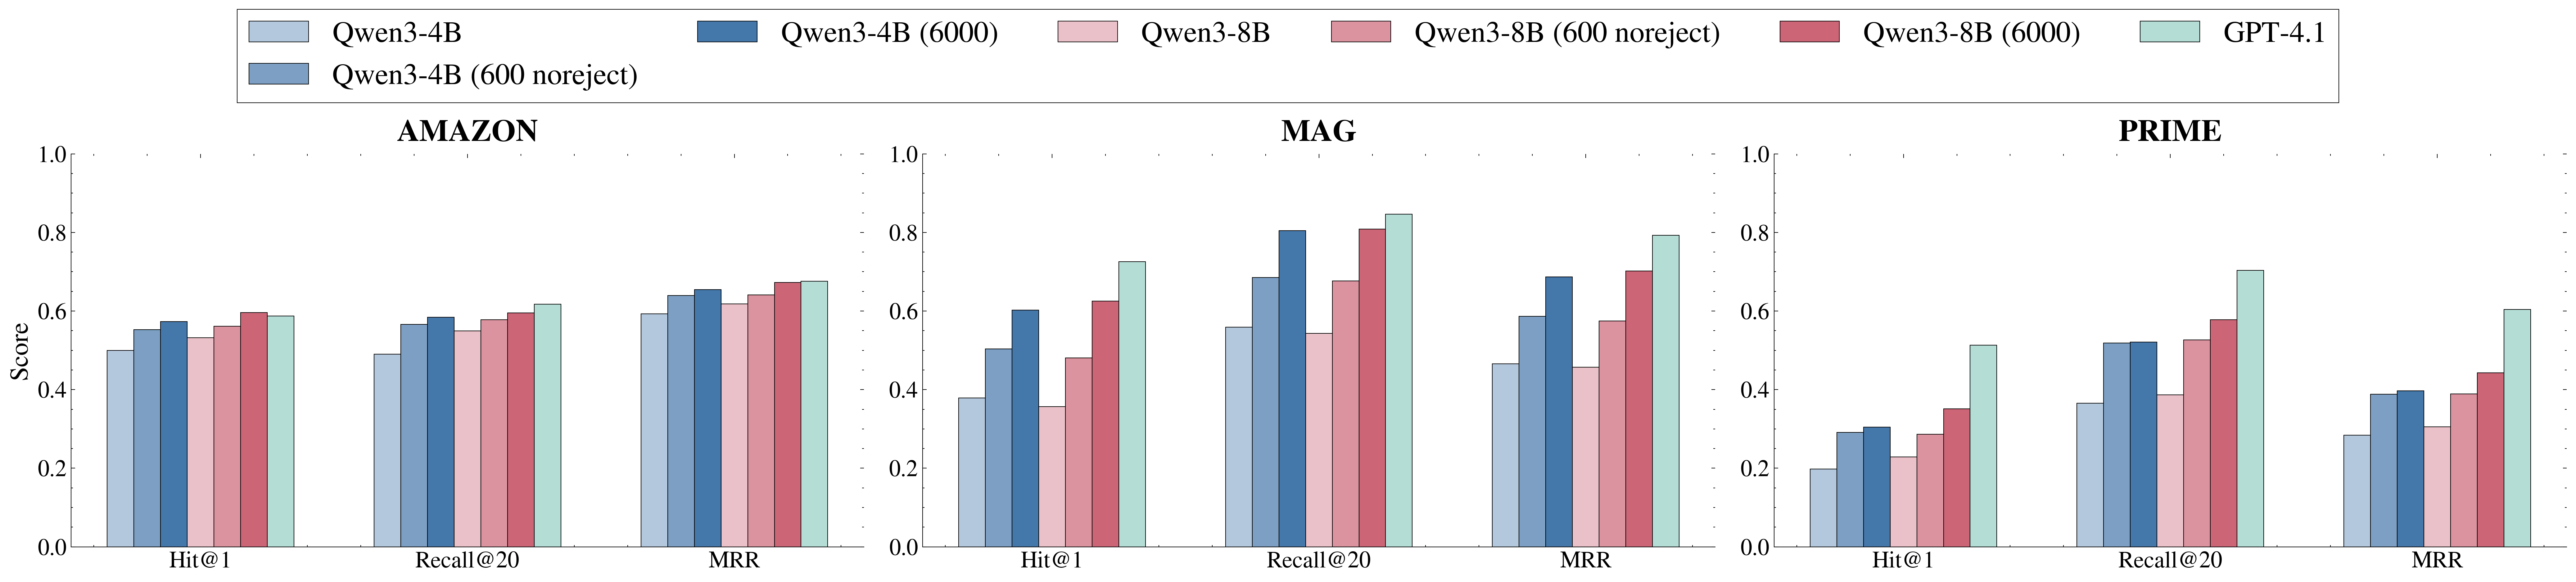

In [8]:
split = "test"

graph_names = ["amazon", "mag", "prime"]

# Base model names (same across all graphs)
base_model_names = {
    "4B": "graph_explorer_Qwen3-4B",
    "8B": "graph_explorer_Qwen3-8B",
}

# Model suffix patterns for finetuned models (graph name will be inserted)
model_suffixes = [
    "graphagent-600-noreject",
    "graphagent-6000",
]

metric_names = ["Hit@1", "Recall@20", "MRR"]

# Helper function to lighten a hex color
def _lighten_color(hex_color, factor):
    """Lighten a hex color by blending with white. factor=0 is original, factor=1 is white."""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

# Base colors (matching plots.ipynb palette)
_blue_full = "#4477AA"
_red_full = "#CC6677"
_teal_full = "#44AA99"

# Lighter versions (base = lightest, distilled 600 = medium, distilled 6000 = full)
_blue_light = _lighten_color(_blue_full, 0.6)   # 60% toward white for base
_blue_medium = _lighten_color(_blue_full, 0.3)  # 30% toward white for distilled 600
_red_light = _lighten_color(_red_full, 0.6)     # 60% toward white for base
_red_medium = _lighten_color(_red_full, 0.3)    # 30% toward white for distilled 600
_teal_light = _lighten_color(_teal_full, 0.6)   # 60% toward white for GPT

# Color scheme using lighter versions - map variant keys to colors
variant_colors = {
    "4B_base": _blue_light,        # Light blue (4B base)
    "4B_noreject": _blue_medium,    # Medium blue (4B 600) - NEW
    "4B_6000": _blue_full,          # Full blue (4B 6000, dark)
    "8B_base": _red_light,          # Light red/pink (8B base)
    "8B_noreject": _red_medium,     # Medium red/pink (8B 600)
    "8B_6000": _red_full,           # Full red/pink (8B 6000, dark)
    "gpt-4.1": _teal_light,         # Light teal (GPT-4.1)
}

# Hatch patterns to distinguish variants
hatch_patterns = {
    "base": None,  # Solid for base
    "noreject": None,  # Solid for 600-noreject
    "6000": None,  # Solid for 6000
}

# Display names for each model variant
display_name_map = {
    "4B_base": "Qwen3-4B",
    "4B_noreject": "Qwen3-4B (600 noreject)",
    "4B_6000": "Qwen3-4B (6000)",
    "8B_base": "Qwen3-8B",
    "8B_noreject": "Qwen3-8B (600 noreject)",
    "8B_6000": "Qwen3-8B (6000)",
    "gpt-4.1": "GPT-4.1",
}

fig, axes = plt.subplots(1, len(graph_names), figsize=(28, 6), sharey=True)
if len(graph_names) == 1:
    axes = [axes]

width = 0.7  # total width allocated for all models at a given metric

for ax, graph_name in zip(axes, graph_names):
    # ----- build performance_df for this graph -----
    performance_df = pd.DataFrame()
    
    # Construct model variants for this graph
    model_variants = []
    
    # Order: 4B base, 4B 600 noreject, 4B 6000, 8B base, 8B 600 noreject, 8B 6000, gpt
    for size in ["4B", "8B"]:
        # Base model
        model_variants.append((f"{size}_base", base_model_names[size]))
        
        # Finetuned models (include graph name)
        for suffix in model_suffixes:
            if "noreject" in suffix:
                variant_key = f"{size}_noreject"
            else:  # 6000
                variant_key = f"{size}_6000"
            finetuned_model_name = f"graph_explorer_{graph_name}-Qwen3-{size}-{suffix}"
            model_variants.append((variant_key, finetuned_model_name))
    
    # GPT-4.1 baseline (last, to show as reference)
    model_variants.append(("gpt-4.1", "graph_explorer_gpt-4.1"))
    
    # Load data for each model variant
    for variant_key, model_name in model_variants:
        logs_dir = Path(f"../data/experiments/{graph_name}/{model_name}/{split}")
        if not logs_dir.exists():
            continue

        df = load_metrics_df(logs_dir, max_agents=3)

        # Add variant_key as suffix to all columns except 'question_id'
        cols_to_rename = {
            col: f"{col}_{variant_key}"
            for col in df.columns
            if col != "question_id"
        }
        df = df.rename(columns=cols_to_rename)

        if len(performance_df) == 0:
            performance_df = df
        else:
            performance_df = performance_df.merge(df, on="question_id", how="inner")

    # If no data for this graph, skip plotting
    if performance_df.empty:
        ax.set_visible(False)
        continue

    # ----- aggregate metrics for this graph -----
    plot_data = []
    for variant_key, model_name in model_variants:
        if f"hit@1_{variant_key}" not in performance_df.columns:
            continue

        n_samples = len(performance_df)
        model_metrics = {
            "Variant": variant_key,
            "Hit@1": performance_df[f"hit@1_{variant_key}"].mean(),
            "Recall@20": performance_df[f"recall@20_{variant_key}"].mean(),
            "MRR": performance_df[f"MRR_{variant_key}"].mean(),
            "Hit@1_se": performance_df[f"hit@1_{variant_key}"].std() / np.sqrt(n_samples),
            "Recall@20_se": performance_df[f"recall@20_{variant_key}"].std() / np.sqrt(n_samples),
            "MRR_se": performance_df[f"MRR_{variant_key}"].std() / np.sqrt(n_samples),
        }
        plot_data.append(model_metrics)

    plot_df = pd.DataFrame(plot_data)
    
    # Ensure the order matches: 4B base, 4B noreject, 4B 6000, 8B base, 8B noreject, 8B 6000, gpt
    variant_order = ["4B_base", "4B_noreject", "4B_6000", "8B_base", "8B_noreject", "8B_6000", "gpt-4.1"]
    plot_df["Variant"] = pd.Categorical(plot_df["Variant"], categories=variant_order, ordered=True)
    plot_df = plot_df.sort_values("Variant")

    # ----- make the barplot for this graph -----
    x = np.arange(len(metric_names))
    n_models = len(plot_df)
    if n_models == 0:
        ax.set_visible(False)
        continue

    # Apply unified axis styling
    apply_axis_styling(ax)
    # Remove the grid (matching third_figure style)
    ax.grid(False)

    # Plot bars for each model
    for i, row in plot_df.iterrows():
        values = [row[m] for m in metric_names]
        errors = [row[f"{m}_se"] for m in metric_names]
        offset = (i - n_models / 2 + 0.5) * width / n_models
        label = display_name_map.get(row["Variant"], row["Variant"]) if ax is axes[0] else None
        
        # Determine color and hatch based on variant key
        variant = row["Variant"]
        color = variant_colors.get(variant, "gray")
        if variant == "gpt-4.1":
            hatch = None  # Solid for GPT-4.1
        else:
            variant_type = variant.split("_")[1]  # Extract "base", "noreject", or "6000"
            hatch = hatch_patterns.get(variant_type, None)
        
        ax.bar(
            x + offset,
            values,
            width / n_models,
            label=label,
            color=color,
            edgecolor=STYLE['bar_edgecolor'],
            linewidth=STYLE['bar_linewidth'],
            hatch=hatch
        )

    ax.set_ylim(0, 1)
    # Set y-ticks from 0 to 1 - show on all graphs
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels([f'{tick:.1f}' for tick in np.arange(0, 1.01, 0.2)], 
                      fontsize=STYLE['tick_label_fontsize'])
    # Explicitly show y-ticks on all subplots
    ax.tick_params(axis='y', which='major', labelsize=STYLE['tick_label_fontsize'], labelleft=True)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, 
                       rotation=0, ha="center",
                       fontsize=STYLE['tick_label_fontsize'])
    
    # Y-axis label: only on first column (left side)
    if ax is axes[0]:
        ax.set_ylabel("Score",
                     fontsize=STYLE['axis_label_fontsize'],
                     fontweight=STYLE['axis_label_fontweight'])
    
    # Title: graph name on top of each column
    ax.set_title(graph_name.upper(),
                fontsize=STYLE['title_fontsize'],
                fontweight=STYLE['title_fontweight'],
                pad=STYLE['title_pad'])
        
    print(len(performance_df))

# Only one legend for the whole figure - ensure order matches plot
handles, labels = axes[0].get_legend_handles_labels()
variant_order = ["4B_base", "4B_noreject", "4B_6000", "8B_base", "8B_noreject", "8B_6000", "gpt-4.1"]
display_name_order = [display_name_map[v] for v in variant_order if v in display_name_map]

# Reorder handles and labels to match desired order
ordered_handles = []
ordered_labels = []
for label in display_name_order:
    if label in labels:
        idx = labels.index(label)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

legend = fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper center",
    ncol=min(len(ordered_labels), 6),
    bbox_to_anchor=(0.5, 1.08),
    frameon=STYLE['legend_frameon'],
    fancybox=STYLE['legend_fancybox'],
    shadow=STYLE['legend_shadow'],
    framealpha=STYLE['legend_framealpha'],
    edgecolor=STYLE['legend_edgecolor'],
    fontsize=STYLE['legend_fontsize'] + 5,
    handlelength=2.0,
    handletextpad=0.8,
    columnspacing=2.0,
)
apply_legend_styling(legend)

fig.tight_layout(rect=[0, 0, 1, 0.90])
os.makedirs("../data/figures", exist_ok=True)
plt.savefig(f"../data/figures/distill_size.png",
           bbox_inches='tight',
           dpi=STYLE['fig_dpi'],
           facecolor=STYLE['fig_facecolor'])
plt.show()